# Exercise 4a 

Deadline 18.12.2025

Anna Bütfering

Lea Neumann

Juan Provencio

## 1. Simulation setup

The physics way to simulate epidemiology depends on the following differential equations:

$$ \dot{S} = - \lambda \dfrac{S \cdot I}{N} $$

$$ \dot{I} = \lambda \dfrac{S \cdot I}{N} - \mu \cdot I $$

$$ \dot{R} = \mu \cdot I $$

with the constraint

$$ N = S + I + R $$

of the total population.

These equations are discretized $\mathrm{d} t\to \Delta t$ for sequences of days $\Delta t = 1 \mathrm{\,day}$  where the progress of the epidemic is tracked. Therefore, e.g. $\Delta S(t) = S(t - 1) - S(t)$. We also normalize the equations so that they're independent of population size $N$. We simulate the evolution by solving for the current values:

$$ S(t+\Delta t)=S(t)−\lambda S(t)I(t) \Delta t $$

$$I(t + \Delta t) = I(t) + (\lambda S(t) I(t) - \mu I(t)) \Delta t $$

$$ R(t + \Delta t) = R(t) + \mu I(t) \Delta t $$

etc.

In [24]:
# Torch
import numpy as np # added after submission!
import torch 
from torch import nn, optim
from torch import sqrt, exp
# Sklearn
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
# Etc.
import matplotlib.pyplot as plt
from tqdm import tqdm
## Plot options
from cycler import cycler
from matplotlib import rcParams
rcParams['axes.grid'] = True
rcParams['grid.linestyle'] = '--'
rcParams['grid.alpha'] = 0.5
rcParams['axes.labelsize'] = 20
rcParams['axes.prop_cycle'] = cycler('color', ['#C61A27', '#3891A6', \
                                               '#F79D65', '#FDE74C', \
                                                '#9BC53D', '#5BC0EB',
                                                '#E55934', '#FA7921',
                                                '#8D230F', '#1B998B'])
colors = rcParams['axes.prop_cycle'].by_key()['color']
rcParams['axes.titlesize'] = 22
rcParams['figure.figsize'] = (12, 7)
rcParams['figure.titlesize'] = 26
rcParams['font.size'] = 16
rcParams['image.cmap'] = 'magma'
rcParams['lines.markeredgewidth'] = 2
rcParams['lines.markerfacecolor'] = 'white'
rcParams['markers.fillstyle'] = 'none'
# Define textbox style for plots
textbox_style = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='black')


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/usr/local/Cellar/python@3.10/3.10.17/Frameworks/Python.framework/Versions/3.10/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/usr/local/Cellar/python@3.10/3.10.17/Frameworks/Python.framework/Versions/3.10/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/Users/juancarlospl/Downloads/Uni/Skripts/GNNS/Exercises/.venv/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instan

First, we implement a simulation of the SIR model. It's important to choose appropriate starting conditions.

Text(0.5, 0, 'Time')

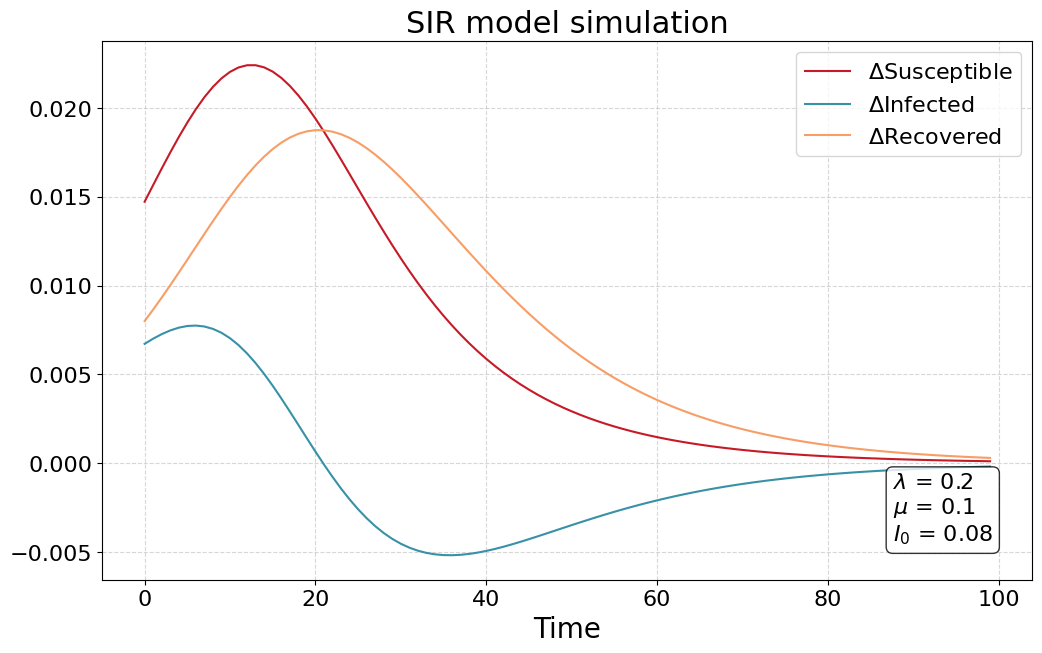

In [49]:
# Simple SIR simulation
def simulate_sir_simple(lam, mu, I_0, T, Delta_t = 1.0):
    # Initialize starting conditions
    S_0 = 1.0 - I_0
    R_0 = 0.0
    # Time evolution
    S = S_0
    I = I_0
    R = R_0
    x = []
    c = []
    for t in range(T):
        # Update equations
        x.append((lam * S * I * Delta_t, 
                  lam * S * I * Delta_t - mu * I * Delta_t, 
                  mu * I * Delta_t))
        c.append((S, I, R))
        # Next step
        S = S - lam * S * I * Delta_t
        I = I + lam * S * I * Delta_t - mu * I * Delta_t
        R = R + mu * I * Delta_t

        #print(S + I + R)  # This should always be 1, 
        # but it's not exactly due to numerical error from the discretization

    return x, c

params = [0.2, 0.1, 0.08]
x, c = simulate_sir_simple(lam = params[0], mu = params[1], I_0 = params[2], 
                        T = 100, Delta_t = 1.0)

fig = plt.figure()
plt.plot(np.array(x)[:,0], label='$\Delta$Susceptible')
plt.plot(np.array(x)[:,1], label='$\Delta$Infected')
plt.plot(np.array(x)[:,2], label='$\Delta$Recovered')
plt.title('SIR model simulation')
# Parameter box
param_text = f"$\\lambda$ = {params[0]}\n$\\mu$ = {params[1]}\n$I_0$ = {params[2]}"
plt.gca().text(0.85, 0.2, param_text, transform=plt.gca().transAxes, fontsize=16,
        verticalalignment='top', bbox=textbox_style)
plt.legend()
plt.xlabel('Time')

        

We run different simulations for different starting parameters and find such that the epidemics are interesting, e.g. don't already end by day 30, i.e. the change in infections should not stabilize too soon, and don't unfold only after day 70, i.e. the change in infections spikes too late.

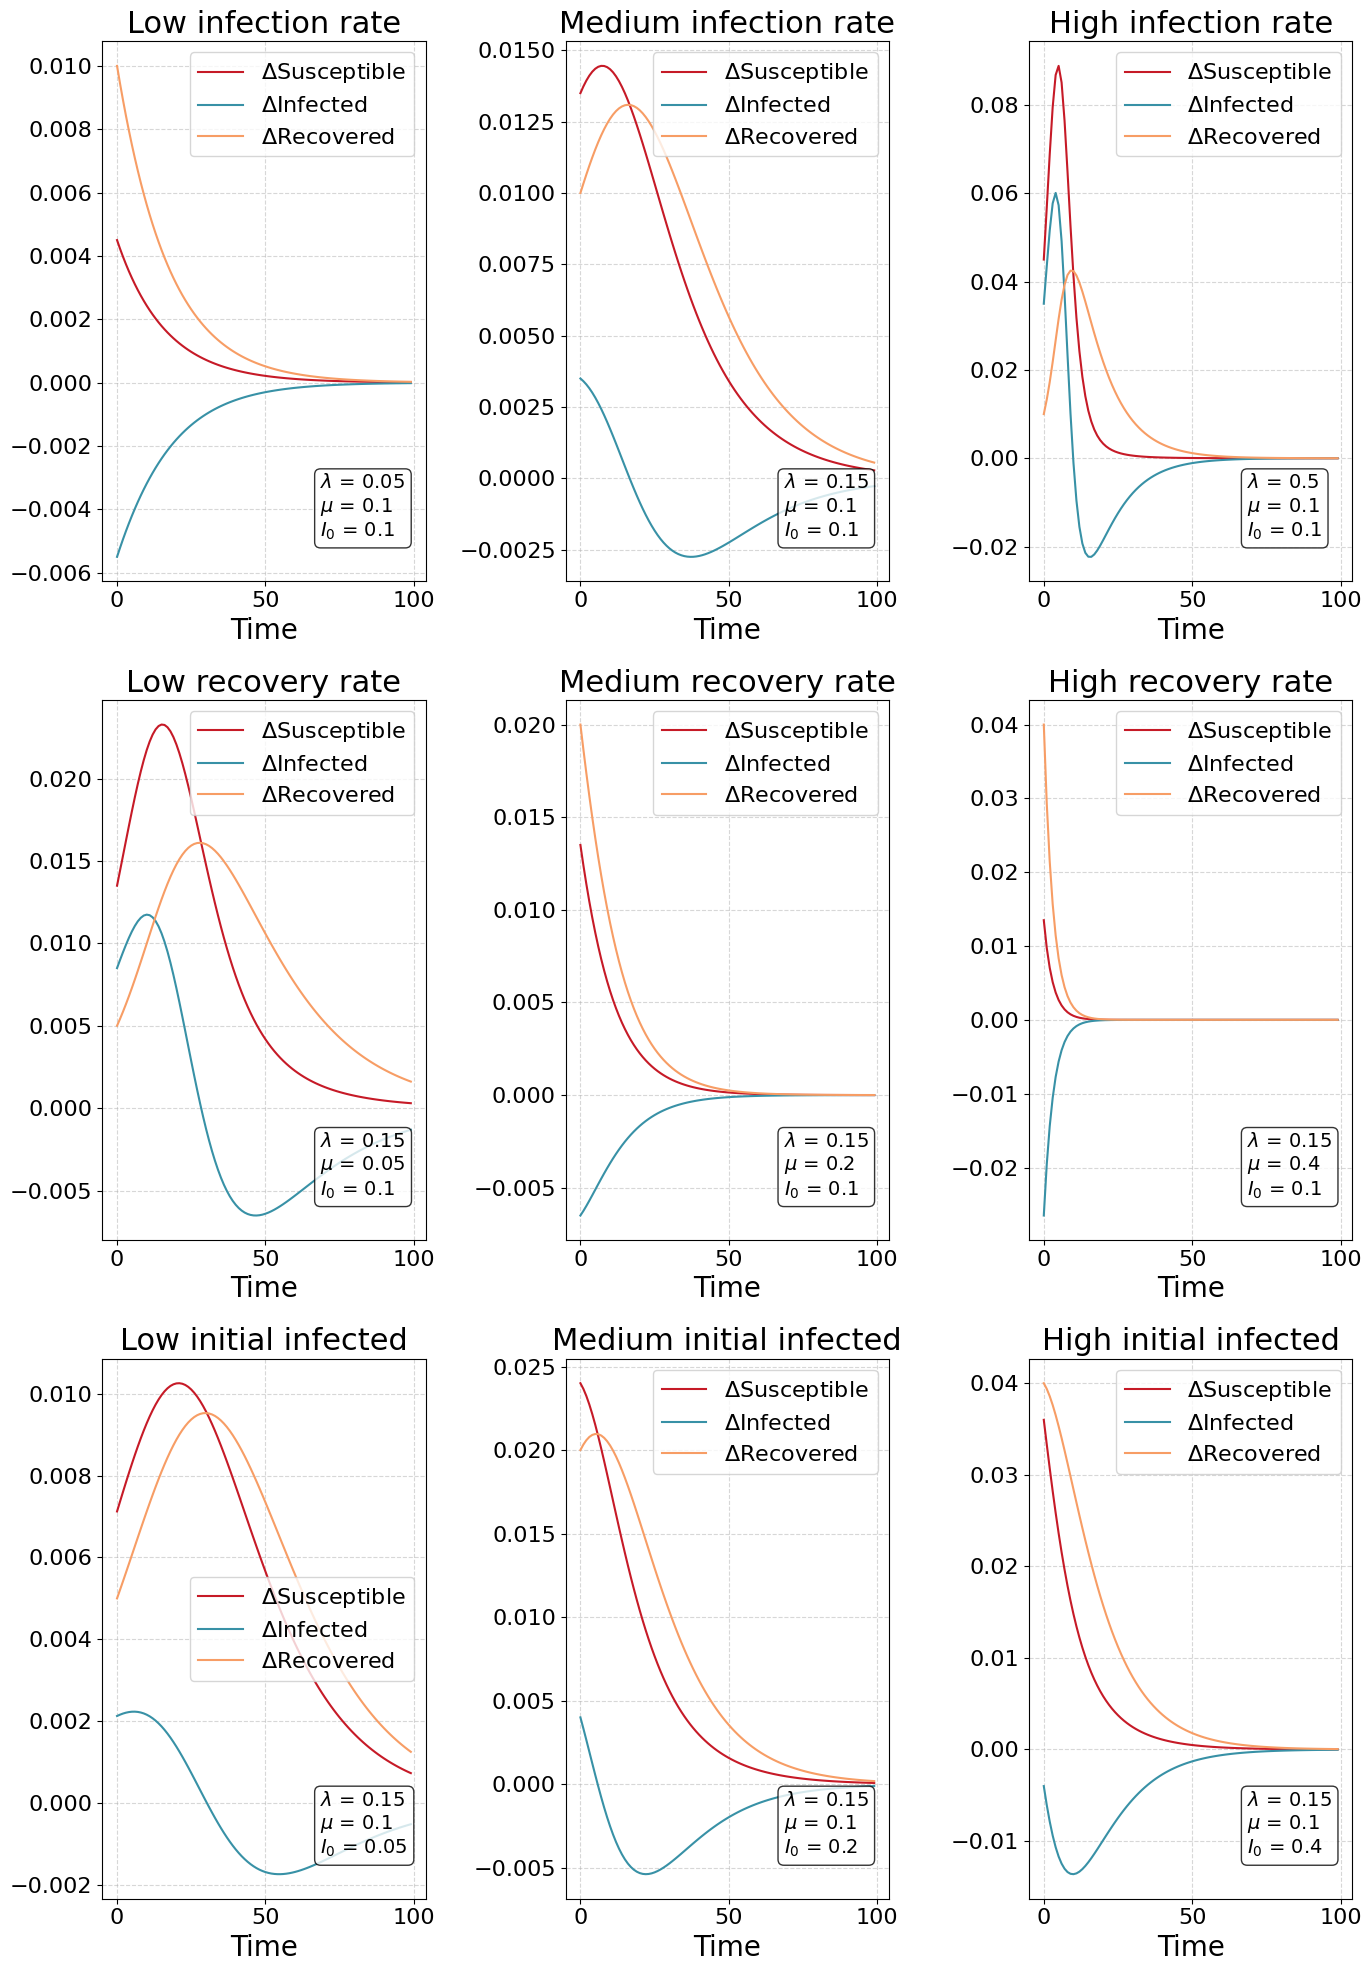

In [76]:
params = [(0.05, 0.1, 0.1), (0.15, 0.1, 0.1), (0.5, 0.1, 0.1), 
          (0.15, 0.05, 0.1), (0.15, 0.2, 0.1), (0.15, 0.4, 0.1), 
          (0.15, 0.1, 0.05), (0.15, 0.1, 0.2), (0.15, 0.1, 0.4)]
titles = ['Low infection rate', 'Medium infection rate', 'High infection rate',
          'Low recovery rate', 'Medium recovery rate', 'High recovery rate',
          'Low initial infected', 'Medium initial infected', 'High initial infected']

fig, axes = plt.subplots(3, 3, figsize=(14,20))
for i, ax in enumerate(axes.flatten()):
    x, c = simulate_sir_simple(lam = params[i][0], mu = params[i][1], I_0 = params[i][2], 
                            T = 100, Delta_t = 1.0)
    ax.plot(np.array(x)[:,0], label='$\Delta$Susceptible')
    ax.plot(np.array(x)[:,1], label='$\Delta$Infected')
    ax.plot(np.array(x)[:,2], label='$\Delta$Recovered')
    ax.set_title(titles[i])
    # Parameter box
    param_text = f"$\\lambda$ = {params[i][0]}\n$\\mu$ = {params[i][1]}\n$I_0$ = {params[i][2]}"
    ax.text(0.675, 0.2, param_text, transform=ax.transAxes, fontsize=14,
            verticalalignment='top', bbox=textbox_style)
    ax.legend()
    ax.set_xlabel('Time')
fig.tight_layout()

From these experiments we define the simulation prior

$$ p^{\mathrm{sim}}(Y) = p^{\mathrm{sim}}(\lambda) \cdot p^{\mathrm{sim}}(\mu) \cdot p^{\mathrm{sim}}(I_0) $$

Our observations lead to excluding very high recovery rates, in particular with respect to the infection rates. In those cases, the disease is erradicated very quickly. Similarly for very high infection rates in comparison to the recovery rates. In the most interesting distributions, there isn't a large difference between the infection rate $\lambda$ and recovery rate $\mu$. A slightly higher infection rate than recovery rate provides the most diverse curves. We decide to sample:

$$ p^{\mathrm{sim}}(\lambda) = \mathrm{uniform}(0.1, 0.4) $$

$$ p^{\mathrm{sim}}(\mu) = \mathrm{uniform}(0.05, 0.25) $$

$$ p^{\mathrm{sim}}(I_0) = \mathrm{uniform}(0.05, 0.4) $$

Although there is obviously a lot of arbitrarity to this choice.

## 2. Point estimation